In [ ]:
!pip install open_clip_torch

import open_clip
import torch
from PIL import Image
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)

model.eval()

image = preprocess(Image.open(image_path)).unsqueeze(0)

with torch.no_grad():
    features = model.encode_image(image)

embedding = features.cpu().numpy().flatten().tolist()

print("CLIP Embedding Length:", len(embedding))
print("CLIP Output:", embedding)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00


Saving 79.jpg to 79.jpg


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Embedding Length: 512
CLIP Output: [-0.3246375620365143, 0.038085732609033585, 0.0881114974617958, 0.49117863178253174, 0.37236133217811584, 0.38691580295562744, 0.22849713265895844, 0.2708933353424072, 0.058826591819524765, -0.3291979134082794, 0.11189880222082138, 0.24454163014888763, -1.0513988733291626, -0.4103674590587616, 0.27441367506980896, 0.009655755944550037, 0.2920437157154083, -0.3184141218662262, 0.5806224942207336, -0.2605281174182892, -0.18228815495967865, 0.11669062077999115, 0.37713003158569336, -0.26310795545578003, -0.19444796442985535, 0.05124512314796448, 0.1698874533176422, -0.03319066762924194, 0.28477421402931213, 0.048468492925167084, 0.39469438791275024, 0.24079212546348572, 0.17524586617946625, -0.4362297058105469, 0.21272534132003784, -0.18380679190158844, -0.24227596819400787, -0.2473287284374237, 0.21231555938720703, 0.3887123465538025, 0.18914787471294403, 0.13896815478801727, 0.31061965227127075, 0.09221575409173965, 0.03430210053920746, -1.5880559

In [ ]:
!pip install transformers

from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
from google.colab import files

# Upload Image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load BLIP
processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
# Load image
image = Image.open(image_path).convert("RGB")
inputs = processor(image, return_tensors="pt")
output = model.generate(**inputs)
caption = processor.decode(output[0], skip_special_tokens=True)

print("BLIP Caption:", caption)

Saving 79.jpg to 79 (2).jpg


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

BLIP Caption: a small plant in the middle of a dirt field


Saving 79.jpg to 79 (4).jpg

image 1/1 /content/79 (4).jpg: 480x640 3 potted plants, 9.2ms
Speed: 2.3ms preprocess, 9.2ms inference, 35.3ms postprocess per image at shape (1, 3, 480, 640)
Detections: [{'label': 'potted plant', 'confidence': 0.1500251740217209, 'bbox': [0, 1, 596, 450]}, {'label': 'potted plant', 'confidence': 0.05721675977110863, 'bbox': [272, 0, 598, 371]}, {'label': 'potted plant', 'confidence': 0.05179251730442047, 'bbox': [2, 1, 400, 448]}]


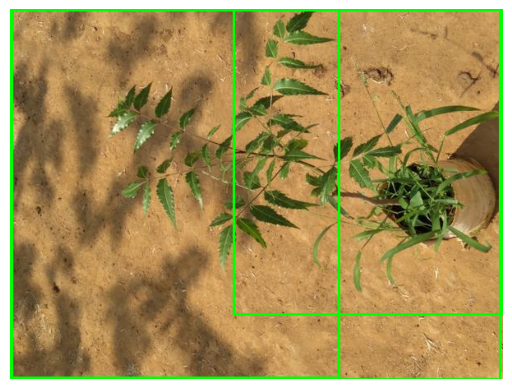

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
model = YOLO("yolov8n.pt")
results = model.predict(
    source=image_path,
    conf=0.05,
    imgsz=640,
    save=False
)
img = cv2.imread(image_path)# Read image
detections = []
for r in results:
    if r.boxes is None:
        print("No detections found")
        continue
    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy()
    for box, conf, cls in zip(boxes, confs, classes):
        label = model.names[int(cls)]
        x1, y1, x2, y2 = map(int, box)
        detections.append({
            "label": label,
            "confidence": float(conf),
            "bbox": [x1, y1, x2, y2]
        })
        cv2.rectangle(img, (x1,y1),(x2,y2),(0,255,0),2)  # draw bounding box
        cv2.putText(img,label,(x1,y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,(0,255,0),2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
print("Detections:", detections)